## Step 1 & 2: Load and Merge Data

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import folium

# Allow inline display of plots
%matplotlib inline

print("--- Step 1 & 2: Loading and Merging Data ---")

# Load your dataset
df = pd.read_csv("../1_datasets/cleaned_datasets/clean_merged_data.csv")

# Load country coordinates dataset from a public source
country_coords_url = "https://raw.githubusercontent.com/google/dspl/master/samples/google/canonical/countries.csv"
country_coords = pd.read_csv(country_coords_url)

# Keep only relevant columns and rename for merging
country_coords = country_coords[["name", "latitude", "longitude"]]
country_coords = country_coords.rename(columns={"name": "Country"})

# Merge on Country column
df_merged = pd.merge(df, country_coords, on="Country", how="left")

# Remove rows without coordinates
df_merged.dropna(subset=["latitude", "longitude"], inplace=True)

# Display merged data
df_merged.head()

--- Step 1 & 2: Loading and Merging Data ---


,Country,Year,SDI,PM2.5,All-cause DALYs,Cardiovascular DALYs,Stroke DALYs,Respiratory DALYs,latitude,longitude
0,Georgia,2010,0.805882,22.84,1312.882621,977.414421,407.617311,43.139413,42.315407,43.356892
1,Georgia,2011,0.811503,25.98,1270.511194,894.030277,363.367273,48.459765,42.315407,43.356892
2,Georgia,2012,0.815983,25.60,1327.455940,912.853130,364.818925,51.909633,42.315407,43.356892
3,Georgia,2013,0.820060,23.92,1384.849753,946.309316,387.791719,55.317720,42.315407,43.356892
4,Georgia,2014,0.823730,22.76,1419.667517,972.114994,410.655051,55.280263,42.315407,43.356892


## Dataset Info

In [14]:
# Show general info about the merged dataset
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1700 entries, 0 to 1949
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               1700 non-null   object 
 1   Year                  1700 non-null   int64  
 2   SDI                   1700 non-null   float64
 3   PM2.5                 1700 non-null   float64
 4   All-cause DALYs       1700 non-null   float64
 5   Cardiovascular DALYs  1700 non-null   float64
 6   Stroke DALYs          1700 non-null   float64
 7   Respiratory DALYs     1700 non-null   float64
 8   latitude              1700 non-null   float64
 9   longitude             1700 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 146.1+ KB


## Step 3: Standardize Features for Clustering

In [22]:
print("\n--- Step 3: Preparing Data for K-means ---")

# Select relevant features
features = [
    "SDI",
    "PM2.5",
    "All-cause DALYs",
    "Cardiovascular DALYs",
    "Stroke DALYs",
    "Respiratory DALYs",
    "latitude",
    "longitude",
]

X = df_merged[features].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()


--- Step 3: Preparing Data for K-means ---


,SDI,PM2.5,All-cause DALYs,Cardiovascular DALYs,Stroke DALYs,Respiratory DALYs,latitude,longitude
0,1.040072,0.015974,0.048299,0.482945,0.695463,-0.603755,0.994753,0.411598
1,1.070466,0.226482,0.002721,0.350310,0.486362,-0.545142,0.994753,0.411598
2,1.094686,0.201007,0.063975,0.380250,0.493221,-0.507135,0.994753,0.411598
3,1.116733,0.088378,0.125712,0.433467,0.601778,-0.469588,0.994753,0.411598
4,1.136576,0.010611,0.163165,0.474515,0.709818,-0.470001,0.994753,0.411598


##  Step 4: Determine Optimal Number of Clusters 


--- Step 4: Determining Optimal K using Elbow Method ---


c:\Users\saade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\saade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\saade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\saade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

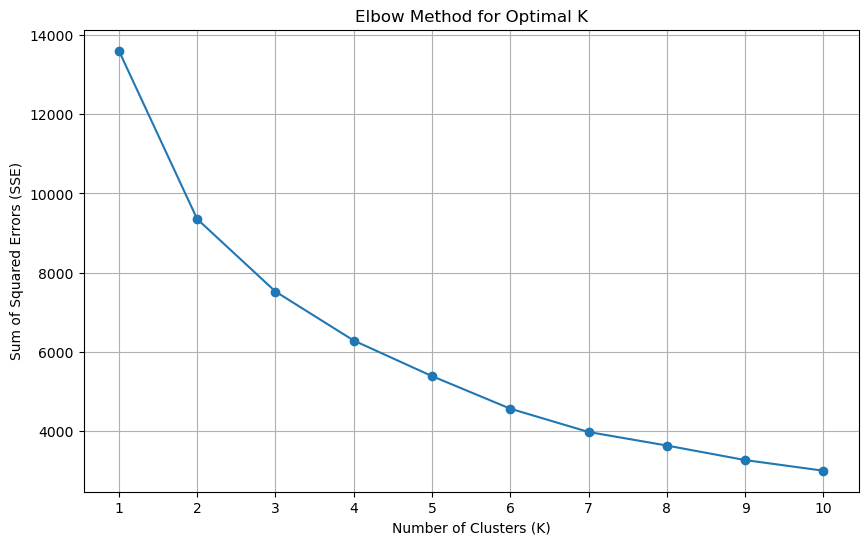

In [23]:
print("\n--- Step 4: Determining Optimal K using Elbow Method ---")

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot the SSE vs K graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Step 5: Apply K-means Clustering

In [24]:
print("\n--- Step 5: Performing K-means Clustering ---")

# Choose K based on the Elbow graph. Adjust if needed.
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Add cluster labels to DataFrame
df_merged["Cluster"] = kmeans_model.fit_predict(X_scaled)

# Show data with cluster labels
df_merged[["Country", "Year", "Cluster"]].head()


--- Step 5: Performing K-means Clustering ---


c:\Users\saade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


,Country,Year,Cluster
0,Georgia,2010,2
1,Georgia,2011,2
2,Georgia,2012,2
3,Georgia,2013,2
4,Georgia,2014,2


## Step 6: Visualize Clusters on World Map 

In [25]:
print("\n--- Step 6: Visualizing Clusters on World Map ---")

# Create base map
m = folium.Map(location=[0, 0], zoom_start=2)

# Define color palette
colors = [
    "red",
    "blue",
    "green",
    "purple",
    "orange",
    "darkred",
    "lightred",
    "beige",
    "darkblue",
    "darkgreen",
    "cadetblue",
    "darkpurple",
    "white",
    "pink",
    "lightblue",
    "lightgreen",
    "gray",
    "black",
    "lightgray",
]

# Add points by cluster
for idx, row in df_merged.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color=colors[row["Cluster"] % len(colors)],
        fill=True,
        fill_color=colors[row["Cluster"] % len(colors)],
        fill_opacity=0.7,
        tooltip=folium.Tooltip(
            f"Country: {row['Country']}<br>Year: {row['Year']}<br>Cluster: {row['Cluster']}<br>"
            f"SDI: {row['SDI']}<br>PM2.5: {row['PM2.5']}"
        ),
    ).add_to(m)

# Save and optionally display the map
map_file_path = "world_map_clusters.html"
m.save(map_file_path)
m  # This will display the map in Jupyter (if supported)


--- Step 6: Visualizing Clusters on World Map ---
